# Backbone DS pipeline

## 0. Set up

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Saving models
import joblib

# Prettier plots
sns.set(style="whitegrid")

## 1. Load Dataset

In [2]:
# Load Titanic dataset
df = sns.load_dataset('titanic') # or pd.read_csv('titanic.csv') if the data is in a csv file

# Preview the dataset
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 2. Exploratory Data Analysis (EDA)

EDA helps us understand:

- The shape and structure of the data

- Missing values

- Distributions and potential outliers

- Relationships between features and the target

### 2.1 Quick Overview

In [3]:
# Shape and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


### 2.2 Statistical Summary


In [4]:
# Summary statistics for numerical columns
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### 2.3 Check for Missing Values

In [5]:
# Count of missing values
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

### 2.4 Preview Class Balance


In [6]:
# How many survived vs not survived
df['survived'].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

### 2.5 Visualize Distributions


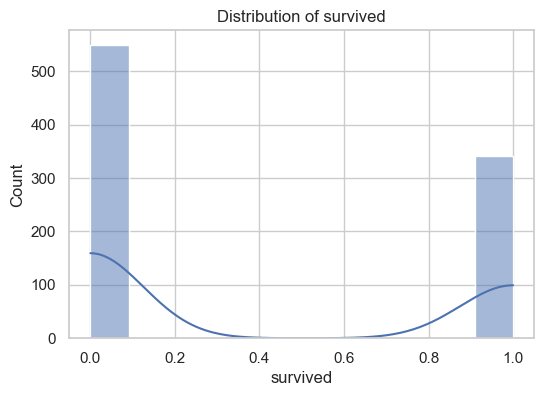

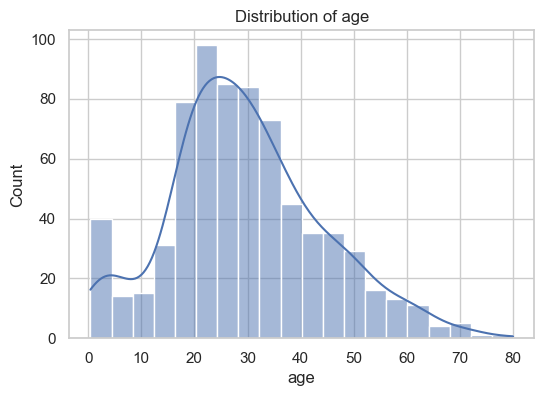

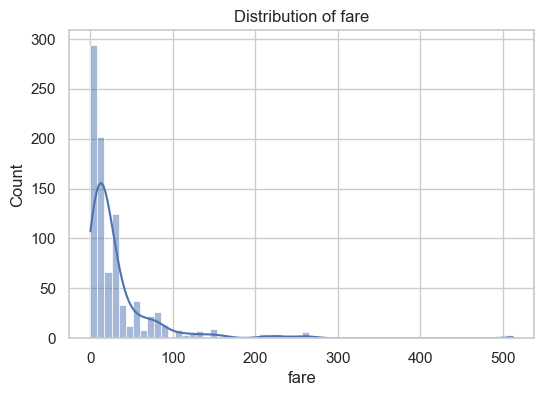

In [10]:
# Numeric columns only
numeric_cols = df.select_dtypes(include='number').columns

# Drop the columns that are not needed
numeric_cols = numeric_cols.drop(['pclass', 'sibsp', 'parch'])

# Plot the distributions of the numeric columns
for col in numeric_cols:
    # Create a figure with a specific size (6 inches wide, 4 inches high)
    plt.figure(figsize=(6, 4))
    # Drop missing values and plot the distribution
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

### 2.6 Visualize Target Variable by Category

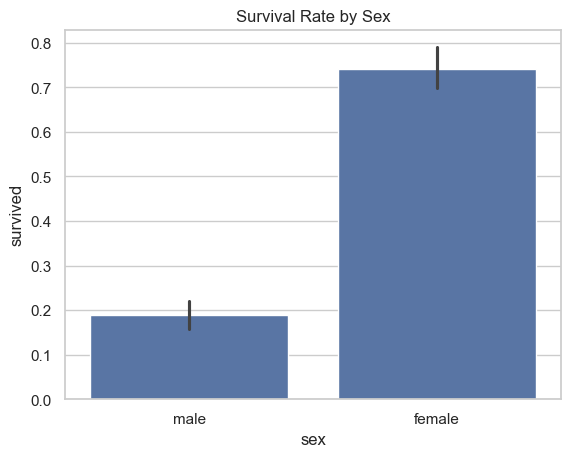

In [8]:
# Example: Survival rate by sex
sns.barplot(x='sex', y='survived', data=df)
plt.title('Survival Rate by Sex')
plt.show()

## 3. Data Preprocessing

We’ll do three things here:

- Define our target and features

- Handle missing values

- Create a preprocessing pipeline that: Scales numeric features, Encodes categorical features, Split into training and test sets

### 3.1 Define the target and features


In [12]:
# Our target is 'survived'
target_column = 'survived'

# Drop rows with missing 'embarked' or 'age' (keep it simple for now)
df_clean = df.dropna(subset=['embarked', 'age'])

# Drop columns we won’t use (e.g., 'deck', 'embark_town', 'alive', 'who')
df_clean = df_clean.drop(columns=['deck', 'embark_town', 'alive', 'who'])

# Define features (X) and target (y)
X = df_clean.drop(columns=[target_column]) # Features (all columns except the target)
y = df_clean[target_column] # Target (the target column)


### 3.2 Train/Test Split


In [14]:
from sklearn.model_selection import train_test_split

# Split the data into training and test sets
# 20% of the data will be used for testing
# 80% of the data will be used for training
# The random state is set to 42 to ensure reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### 3.3 Identify column types

In [15]:
# Which columns are numeric? # We will use this to scale the numeric columns
num_features = X.select_dtypes(include='number').columns.tolist()

# Which columns are categorical? # We will use this to encode the categorical columns
cat_features = X.select_dtypes(include='object').columns.tolist()

print("Numerical:", num_features)
print("Categorical:", cat_features)


Numerical: ['pclass', 'age', 'sibsp', 'parch', 'fare']
Categorical: ['sex', 'embarked']


### 3.4 Build Preprocessing Pipeline


In [16]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Pipeline for numerical features # We will use this to scale the numeric columns
numeric_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

# Pipeline for categorical features # We will use this to encode the categorical columns
categorical_pipeline = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine both # We will use this to combine the numeric and categorical pipelines
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, num_features),
    ('cat', categorical_pipeline, cat_features)
])


## 4. Model Training

We’ll now:

Combine the preprocessing pipeline with a model

Train the pipeline on the training data

### 4.1 Build the Full Pipeline

We’ll use a RandomForestClassifier inside the pipeline:

In [17]:
from sklearn.ensemble import RandomForestClassifier

# We will use this to combine the preprocessing pipeline and the model
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

### 4.2 Train the Model

In [18]:
# Fit the pipeline on the training data
model_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


That’s it! The pipeline:

Preprocesses the training data (scaling, encoding)

Trains the random forest on the processed features

### 4.3 Check training accuracy [Optional] 

In [19]:
# Evaluate the pipeline on the training data
train_preds = model_pipeline.predict(X_train)
print("Training accuracy:", (train_preds == y_train).mean())


Training accuracy: 0.9876977152899824


## 5. Model Evaluation

We’ll now:

Make predictions on the test set

Use classification metrics (accuracy, precision, recall, F1-score)

View the confusion matrix

### 5.1 Predict on Test Set

In [20]:
# Predict on test set
# We will use the model pipeline to predict on the test set
y_pred = model_pipeline.predict(X_test)

### 5.2 Print Evaluation Metrics


In [23]:
from sklearn.metrics import classification_report, confusion_matrix

# Classification report 
# We will use this to evaluate the performance of the model
print(classification_report(y_test, y_pred))

# Confusion matrix 
# We will use this to visualize the performance of the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.82      0.80        80
           1       0.75      0.68      0.72        63

    accuracy                           0.76       143
   macro avg       0.76      0.75      0.76       143
weighted avg       0.76      0.76      0.76       143

Confusion Matrix:
[[66 14]
 [20 43]]


⚖️ Summary:
The model is better at predicting non-survivors than survivors

Still, performance is reasonable on both classes